# 09 – Threshold-Optimierung und Strategy Feasibility

## Ziel

Dieses Notebook dokumentiert die bereits abgeschlossene wirtschaftliche Bewertung der BTCUSDT-Prognosemodelle für die untersuchten Horizonte.

Es beantwortet insbesondere:

- Welche Modell- und Kalibrierungskombination wurde je Horizont bewertet?
- Welche Schwellenwerte wurden in den verschachtelten Walk-Forward-Folds untersucht?
- Warum wurde gegebenenfalls `No Trade` gewählt?
- Welche Bestandteile umfasst das angenommene Kostenmodell?
- Bis zu welcher Kostenstufe existiert eine robuste Region?
- Welcher Horizont war explorativ am stärksten?
- Warum wurde der finale Test nicht geöffnet?

## Sicherheitsgrenzen

Dieses Notebook:

- optimiert **keine** Schwellenwerte neu,
- trainiert **keine** Modelle,
- führt **kein** neues Backtesting aus,
- verwendet **keinen** Holdout zur nachträglichen Auswahl,
- greift **nicht** auf den finalen Testsplit zu,
- liest ausschließlich gespeicherte Threshold- und Feasibility-Artefakte.

Notebook 08 behandelte die statistische Modell- und Kalibrierungsauswahl. Notebook 09 prüft, ob daraus unter realistischen Kosten ein wirtschaftlich belastbares Signal entstand.

Anmerkung: Aufgrund der älteren, abweichenden h4-Reportstruktur konnten einzelne detaillierte Kostenoberflächen nicht in allen Darstellungen automatisch zusammengeführt werden. Die h4-Abschlussentscheidung und Kostenrobustheit werden aus den validierten Abschlussartefakten in Notebook 10 übernommen.

## 1. Umgebung und Projektroot

Der Projektroot wird in dieser Reihenfolge bestimmt:

1. Umgebungsvariable `BTC_PROJECT_ROOT`
2. aktuelles Arbeitsverzeichnis
3. Elternverzeichnisse des aktuellen Arbeitsverzeichnisses
4. Pfade mit `reports/final/`

Ein gültiger Projektroot enthält `reports/` und mindestens eines der zentralen Projektmodule.

In [21]:
from __future__ import annotations

import json
import os
import re
from collections import defaultdict
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


EXPECTED_HORIZONS = (4, 16, 96)


def absolute_without_symlink_resolution(
    value: str | Path,
) -> Path:
    return Path(
        os.path.abspath(
            os.fspath(Path(value).expanduser())
        )
    )


def find_project_root() -> Path:
    candidates: list[Path] = []

    environment_root = os.environ.get("BTC_PROJECT_ROOT")
    if environment_root:
        candidates.append(Path(environment_root))

    current = Path.cwd()
    candidates.extend([current, *current.parents])

    seen: set[Path] = set()
    for candidate in candidates:
        absolute = absolute_without_symlink_resolution(candidate)
        if absolute in seen:
            continue
        seen.add(absolute)

        reports_dir = absolute / "reports"
        if reports_dir.exists() and any(
            (absolute / name).exists()
            for name in (
                "config.py",
                "final_project_report.py",
                "threshold_signal_optimization.py",
                "strategy_feasibility_analysis.py",
            )
        ):
            return absolute

        if (reports_dir / "final").exists():
            return absolute

    raise FileNotFoundError(
        "Projektroot nicht gefunden. Setze BTC_PROJECT_ROOT auf "
        "den Ordner 'BTC TSP 15min'."
    )


PROJECT_ROOT = find_project_root()
REPORTS_DIR = PROJECT_ROOT / "reports"
FINAL_REPORT_DIR = REPORTS_DIR / "final"

print(f"Projektroot: {PROJECT_ROOT}")
print(f"Reports:     {REPORTS_DIR}")
print(f"Final:       {FINAL_REPORT_DIR}")

Projektroot: /home/milan/uni/python/BTC TSP/BTC TSP 15min
Reports:     /home/milan/uni/python/BTC TSP/BTC TSP 15min/reports
Final:       /home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final


## 2. Artefakterkennung

Bevorzugt werden die eingefrorenen Referenzen aus:

```text
reports/final/source_runs.json
```

Alternativ sucht das Notebook nach:

```text
reports/**/recommended_threshold.json
reports/**/economic_gate.json
reports/**/feasibility_decision.json
```

Je Horizont wird der neueste vollständige Bericht verwendet. Die tatsächlich ausgewählten Dateien werden sichtbar ausgegeben, damit keine implizite oder versehentliche Quellenmischung entsteht.

In [22]:
def read_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        payload = json.load(handle)
    if not isinstance(payload, dict):
        raise TypeError(f"JSON-Objekt erwartet: {path}")
    return payload


def read_csv_optional(path: Path | None) -> pd.DataFrame:
    if path is None or not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


def recursive_strings(value: Any) -> Iterable[str]:
    if isinstance(value, dict):
        for item in value.values():
            yield from recursive_strings(item)
    elif isinstance(value, list):
        for item in value:
            yield from recursive_strings(item)
    elif isinstance(value, str):
        yield value


def first_present(
    payload: dict[str, Any],
    *keys: str,
    default: Any = None,
) -> Any:
    for key in keys:
        if key in payload and payload[key] is not None:
            return payload[key]
    return default


# Optionaler letzter Rückfall. Normalerweise müssen hier keine Pfade
# eingetragen werden. Bei einer ungewöhnlichen alten Ordnerstruktur kann
# gezielt nur der betroffene Artefaktpfad gesetzt werden.
MANUAL_ARTIFACT_OVERRIDES: dict[int, dict[str, str | None]] = {
    4: {
        "threshold": None,
        "economic_gate": None,
        "feasibility": None,
    },
    16: {
        "threshold": None,
        "economic_gate": None,
        "feasibility": None,
    },
    96: {
        "threshold": None,
        "economic_gate": None,
        "feasibility": None,
    },
}


HORIZON_PATTERNS = (
    re.compile(
        r"target_(?:binary|return|end_time)_(96|16|4)(?!\d)",
        re.IGNORECASE,
    ),
    re.compile(
        r"(?:binary|regression)_h(96|16|4)(?!\d)",
        re.IGNORECASE,
    ),
    re.compile(
        r"(?<![a-z0-9])h(96|16|4)(?!\d)",
        re.IGNORECASE,
    ),
    re.compile(
        r"(?:horizon|cooldown)[_=\- ]+(96|16|4)(?!\d)",
        re.IGNORECASE,
    ),
)


def horizon_from_text(value: Any) -> int | None:
    if value is None:
        return None

    rendered = str(value)
    for pattern in HORIZON_PATTERNS:
        match = pattern.search(rendered)
        if match:
            horizon = int(match.group(1))
            if horizon in EXPECTED_HORIZONS:
                return horizon
    return None


def infer_horizon_shallow(
    payload: dict[str, Any],
    path: Path,
) -> tuple[int | None, str | None]:
    """
    Bestimmt den Horizont aus dem Artefakt selbst.

    Ältere h4-Berichte enthalten teilweise kein explizites
    ``horizon``-Feld und liegen in generischen Reportordnern. Für diese
    Berichte ist ``cooldown_candles=4`` ein zulässiger zusätzlicher
    Hinweis, weil die bestehende Pipeline den Cooldown horizonkonform
    gesetzt hat.
    """
    for key in (
        "horizon",
        "target_horizon",
        "prediction_horizon",
    ):
        value = payload.get(key)
        if value is None:
            continue
        try:
            horizon = int(value)
        except (TypeError, ValueError):
            continue
        if horizon in EXPECTED_HORIZONS:
            return horizon, f"payload.{key}"

    for key in (
        "target_column",
        "return_target_column",
        "target_end_time_column",
        "split_name",
        "binary_dataset_path",
        "regression_dataset_path",
        "return_source_path",
        "source_report_dir",
        "run_dir",
    ):
        horizon = horizon_from_text(payload.get(key))
        if horizon is not None:
            return horizon, f"payload.{key}"

    # Alle eingebetteten Pfade/Strings prüfen. Dadurch werden auch
    # report_paths und source snapshots berücksichtigt.
    for text in recursive_strings(payload):
        horizon = horizon_from_text(text)
        if horizon is not None:
            return horizon, "embedded_payload_string"

    horizon = horizon_from_text(path)
    if horizon is not None:
        return horizon, "artifact_path"

    cooldown = first_present(
        payload,
        "cooldown_candles",
        default=None,
    )
    if cooldown is not None:
        try:
            cooldown_horizon = int(cooldown)
        except (TypeError, ValueError):
            cooldown_horizon = None
        if cooldown_horizon in EXPECTED_HORIZONS:
            return cooldown_horizon, "payload.cooldown_candles"

    return None, None


def normalize_existing_path(
    value: str | Path,
) -> Path | None:
    candidate = Path(value).expanduser()
    if not candidate.is_absolute():
        candidate = PROJECT_ROOT / candidate
    candidate = absolute_without_symlink_resolution(candidate)
    return candidate if candidate.exists() else None


def likely_metadata_files(path: Path) -> list[Path]:
    """
    Liefert nur lokale Begleitdateien desselben Runs.

    Dadurch kann ein generischer ``feasibility_decision.json``-Pfad
    über ``strategy_feasibility_summary.json`` oder
    ``source_threshold_snapshot.json`` h4 zugeordnet werden.
    """
    names = (
        "recommended_threshold.json",
        "recommended_threshold(1).json",
        "source_threshold_snapshot.json",
        "strategy_feasibility_summary.json",
        "threshold_signal_optimization_summary.json",
        "input_validation.json",
        "manifest.json",
    )

    candidates: list[Path] = []
    for directory in (path.parent, path.parent.parent):
        if not directory.exists():
            continue

        for name in names:
            candidate = directory / name
            if candidate.is_file() and candidate != path:
                candidates.append(candidate)

        # Versions- oder Kopienamen ebenfalls berücksichtigen.
        for pattern in (
            "*summary*.json",
            "*snapshot*.json",
            "recommended_threshold*.json",
        ):
            for candidate in directory.glob(pattern):
                if candidate.is_file() and candidate != path:
                    candidates.append(candidate)

    # Reihenfolge erhalten und Duplikate entfernen.
    return list(dict.fromkeys(candidates))


def infer_horizon_deep(
    path: Path,
    *,
    visited: set[Path] | None = None,
) -> tuple[int | None, str | None]:
    """
    Mehrstufige Erkennung für alte und neue Reportstrukturen.
    """
    absolute_path = absolute_without_symlink_resolution(path)
    visited = set() if visited is None else visited

    if absolute_path in visited:
        return None, None
    visited.add(absolute_path)

    try:
        payload = read_json(absolute_path)
    except (OSError, json.JSONDecodeError, TypeError):
        return None, None

    horizon, reason = infer_horizon_shallow(
        payload,
        absolute_path,
    )
    if horizon is not None:
        return horizon, reason

    # Explizit referenzierte Quellordner oder Snapshots prüfen.
    linked_values: list[str] = []
    for key in (
        "source_report_dir",
        "source_threshold_report_dir",
        "source_threshold_path",
        "recommended_threshold_path",
    ):
        value = payload.get(key)
        if isinstance(value, str):
            linked_values.append(value)

    report_paths = payload.get("report_paths")
    if isinstance(report_paths, dict):
        for key in (
            "source_snapshot",
            "recommended_threshold",
            "threshold_summary",
        ):
            value = report_paths.get(key)
            if isinstance(value, str):
                linked_values.append(value)

    for raw in linked_values:
        linked = normalize_existing_path(raw)
        if linked is None:
            continue

        linked_candidates = (
            [linked]
            if linked.is_file()
            else list(linked.glob("recommended_threshold*.json"))
            + list(linked.glob("*summary*.json"))
        )

        for linked_candidate in linked_candidates:
            linked_horizon, linked_reason = infer_horizon_deep(
                linked_candidate,
                visited=visited,
            )
            if linked_horizon is not None:
                return (
                    linked_horizon,
                    f"linked:{linked_candidate.name}:{linked_reason}",
                )

    # Zuletzt lokale Begleitdateien desselben Runs prüfen.
    for metadata_path in likely_metadata_files(absolute_path):
        metadata_horizon, metadata_reason = infer_horizon_deep(
            metadata_path,
            visited=visited,
        )
        if metadata_horizon is not None:
            return (
                metadata_horizon,
                f"sibling:{metadata_path.name}:{metadata_reason}",
            )

    return None, None


def role_for_path(path: Path) -> str | None:
    name = path.name.lower()
    if name.startswith("recommended_threshold"):
        return "threshold"
    if name.startswith("economic_gate"):
        return "economic_gate"
    if name.startswith("feasibility_decision"):
        return "feasibility"
    return None


def reference_overrides_from_final_report(
) -> dict[str, dict[int, Path]]:
    """
    Liest ``source_runs.json`` strukturiert.

    Der Schlüssel ``h4`` beziehungsweise das dortige ``horizon``-Feld
    erzwingt die korrekte Zuordnung selbst dann, wenn der eigentliche
    Artefaktpfad keinen Horizont im Namen enthält.
    """
    result: dict[str, dict[int, Path]] = {
        "threshold": {},
        "economic_gate": {},
        "feasibility": {},
    }

    source_runs_path = FINAL_REPORT_DIR / "source_runs.json"
    if not source_runs_path.exists():
        return result

    source_runs = read_json(source_runs_path)
    runs = source_runs.get("runs")
    if not isinstance(runs, dict):
        return result

    for run_key, run_value in runs.items():
        if not isinstance(run_value, dict):
            continue

        horizon = None
        try:
            candidate = run_value.get("horizon")
            if candidate is not None:
                horizon = int(candidate)
        except (TypeError, ValueError):
            horizon = None

        if horizon not in EXPECTED_HORIZONS:
            match = re.fullmatch(
                r"h(96|16|4)",
                str(run_key).strip(),
                flags=re.IGNORECASE,
            )
            if match:
                horizon = int(match.group(1))

        if horizon not in EXPECTED_HORIZONS:
            continue

        artifact_paths = run_value.get("artifact_paths")
        if isinstance(artifact_paths, dict):
            for role, raw in artifact_paths.items():
                normalized_role = {
                    "recommended_threshold": "threshold",
                    "threshold": "threshold",
                    "economic_gate": "economic_gate",
                    "feasibility_decision": "feasibility",
                    "feasibility": "feasibility",
                }.get(str(role))

                if normalized_role is None or not isinstance(raw, str):
                    continue

                path = normalize_existing_path(raw)
                if path is not None and path.is_file():
                    result[normalized_role][horizon] = path

        run_dir_raw = run_value.get("run_dir")
        if isinstance(run_dir_raw, str):
            run_dir = normalize_existing_path(run_dir_raw)
            if run_dir is not None and run_dir.is_dir():
                patterns = {
                    "threshold": "**/recommended_threshold*.json",
                    "economic_gate": "**/economic_gate*.json",
                    "feasibility": "**/feasibility_decision*.json",
                }
                for role, pattern in patterns.items():
                    candidates = list(run_dir.glob(pattern))
                    if candidates and horizon not in result[role]:
                        result[role][horizon] = max(
                            candidates,
                            key=lambda item: item.stat().st_mtime,
                        )

    return result


def overrides_from_horizon_comparison(
) -> dict[str, dict[int, Path]]:
    result: dict[str, dict[int, Path]] = {
        "threshold": {},
        "economic_gate": {},
        "feasibility": {},
    }

    comparison_path = FINAL_REPORT_DIR / "horizon_comparison.csv"
    frame = read_csv_optional(comparison_path)
    if frame.empty or "horizon" not in frame:
        return result

    for row in frame.to_dict(orient="records"):
        try:
            horizon = int(row.get("horizon"))
        except (TypeError, ValueError):
            continue
        if horizon not in EXPECTED_HORIZONS:
            continue

        run_dir_raw = row.get("run_dir")
        if not isinstance(run_dir_raw, str) or not run_dir_raw:
            continue

        run_dir = normalize_existing_path(run_dir_raw)
        if run_dir is None or not run_dir.is_dir():
            continue

        for role, pattern in {
            "threshold": "**/recommended_threshold*.json",
            "economic_gate": "**/economic_gate*.json",
            "feasibility": "**/feasibility_decision*.json",
        }.items():
            candidates = list(run_dir.glob(pattern))
            if candidates:
                result[role][horizon] = max(
                    candidates,
                    key=lambda item: item.stat().st_mtime,
                )

    return result


def manual_overrides() -> dict[str, dict[int, Path]]:
    result: dict[str, dict[int, Path]] = {
        "threshold": {},
        "economic_gate": {},
        "feasibility": {},
    }

    for horizon, roles in MANUAL_ARTIFACT_OVERRIDES.items():
        if horizon not in EXPECTED_HORIZONS:
            continue
        for role, raw in roles.items():
            if not raw:
                continue
            path = normalize_existing_path(raw)
            if path is None or not path.is_file():
                raise FileNotFoundError(
                    f"Manueller Override existiert nicht: {raw}"
                )
            result[role][horizon] = path

    return result


def discover_candidates() -> dict[str, list[Path]]:
    patterns = {
        "threshold": "**/recommended_threshold*.json",
        "economic_gate": "**/economic_gate*.json",
        "feasibility": "**/feasibility_decision*.json",
    }
    return {
        role: list(REPORTS_DIR.glob(pattern))
        for role, pattern in patterns.items()
    }


def newest_discovered_by_horizon(
    paths: Iterable[Path],
) -> tuple[dict[int, Path], list[dict[str, Any]]]:
    grouped: dict[int, list[Path]] = defaultdict(list)
    diagnostics: list[dict[str, Any]] = []

    for path in paths:
        horizon, reason = infer_horizon_deep(path)
        diagnostics.append(
            {
                "file": str(path),
                "role": role_for_path(path),
                "inferred_horizon": horizon,
                "inference_reason": reason,
                "modified_at": pd.Timestamp(
                    path.stat().st_mtime,
                    unit="s",
                    tz="UTC",
                ),
            }
        )
        if horizon in EXPECTED_HORIZONS:
            grouped[horizon].append(path)

    selected = {
        horizon: max(
            horizon_paths,
            key=lambda item: item.stat().st_mtime,
        )
        for horizon, horizon_paths in grouped.items()
    }
    return selected, diagnostics


all_candidates = discover_candidates()

discovered_paths: dict[str, dict[int, Path]] = {}
diagnostic_rows: list[dict[str, Any]] = []

for role, candidates in all_candidates.items():
    selected, diagnostics = newest_discovered_by_horizon(
        candidates
    )
    discovered_paths[role] = selected
    diagnostic_rows.extend(diagnostics)

comparison_overrides = overrides_from_horizon_comparison()
reference_overrides = reference_overrides_from_final_report()
explicit_overrides = manual_overrides()


def merge_role_paths(role: str) -> dict[int, Path]:
    """
    Priorität:
    automatische Suche
    < horizon_comparison.csv
    < source_runs.json
    < manueller Override
    """
    return {
        **discovered_paths.get(role, {}),
        **comparison_overrides.get(role, {}),
        **reference_overrides.get(role, {}),
        **explicit_overrides.get(role, {}),
    }


threshold_paths = merge_role_paths("threshold")
economic_gate_paths = merge_role_paths("economic_gate")
feasibility_paths = merge_role_paths("feasibility")

available_horizons = sorted(
    set(threshold_paths)
    | set(economic_gate_paths)
    | set(feasibility_paths)
)

candidate_diagnostics = pd.DataFrame(diagnostic_rows)
if not candidate_diagnostics.empty:
    candidate_diagnostics = candidate_diagnostics.sort_values(
        [
            "inferred_horizon",
            "role",
            "modified_at",
        ],
        na_position="last",
    ).reset_index(drop=True)

artifact_overview = pd.DataFrame(
    [
        {
            "horizon": horizon,
            "horizon_hours": horizon * 0.25,
            "threshold_report": str(
                threshold_paths.get(horizon, "")
            ),
            "economic_gate": str(
                economic_gate_paths.get(horizon, "")
            ),
            "feasibility_decision": str(
                feasibility_paths.get(horizon, "")
            ),
            "threshold_found": horizon in threshold_paths,
            "economic_gate_found": horizon in economic_gate_paths,
            "feasibility_found": horizon in feasibility_paths,
        }
        for horizon in EXPECTED_HORIZONS
    ]
)

display(artifact_overview)

missing_expected = sorted(
    horizon
    for horizon in EXPECTED_HORIZONS
    if horizon not in threshold_paths
    or horizon not in feasibility_paths
)

if missing_expected:
    display(
        Markdown(
            "> **Noch unvollständig:** Für "
            + ", ".join(f"h{value}" for value in missing_expected)
            + " fehlt mindestens ein Threshold- oder "
            "Feasibility-Artefakt. Die folgende Diagnosetabelle "
            "zeigt alle gefundenen Kandidaten."
        )
    )
    display(candidate_diagnostics)

if not available_horizons:
    raise FileNotFoundError(
        "Keine Threshold- oder Feasibility-Artefakte gefunden."
    )


,horizon,horizon_hours,threshold_report,economic_gate,feasibility_decision,threshold_found,economic_gate_found,feasibility_found
0,4,1.000000,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/threshold_signal_optimization/20260729T202947619086Z/recommended_threshold.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/threshold_signal_optimization/20260729T202947619086Z/economic_gate.json,,True,True,False
1,16,4.000000,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/threshold/recommended_threshold.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/threshold/economic_gate.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/feasibility/feasibility_decision.json,True,True,True
2,96,24.000000,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/threshold/recommended_threshold.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/threshold/economic_gate.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/feasibility/feasibility_decision.json,True,True,True


> **Noch unvollständig:** Für h4 fehlt mindestens ein Threshold- oder Feasibility-Artefakt. Die folgende Diagnosetabelle zeigt alle gefundenen Kandidaten.

,file,role,inferred_horizon,inference_reason,modified_at
0,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/threshold_signal_optimization/20260729T200241465251Z/economic_gate.json,economic_gate,4,sibling:recommended_threshold.json:payload.cooldown_candles,2026-07-29 20:11:47.376945257+00:00
1,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/threshold_signal_optimization/20260729T202947619086Z/economic_gate.json,economic_gate,4,sibling:recommended_threshold.json:payload.cooldown_candles,2026-07-29 20:38:58.811663151+00:00
2,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/threshold_signal_optimization/20260729T175931497944Z/recommended_threshold.json,threshold,4,payload.cooldown_candles,2026-07-29 18:07:28.857823372+00:00
3,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/threshold_signal_optimization/20260729T200241465251Z/recommended_threshold.json,threshold,4,payload.cooldown_candles,2026-07-29 20:11:47.376945257+00:00
4,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/threshold_signal_optimization/20260729T202947619086Z/recommended_threshold.json,threshold,4,payload.cooldown_candles,2026-07-29 20:38:58.810663223+00:00
5,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/threshold/economic_gate.json,economic_gate,16,artifact_path,2026-07-30 04:15:24.465540886+00:00
6,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/strategy_feasibility_analysis/20260729T210104548551Z/feasibility_decision.json,feasibility,16,embedded_payload_string,2026-07-29 21:01:10.099900007+00:00
7,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/feasibility/feasibility_decision.json,feasibility,16,embedded_payload_string,2026-07-30 04:15:33.047636271+00:00
8,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/feasibility/feasibility_decision.json,feasibility,16,embedded_payload_string,2026-07-30 09:22:24.881875277+00:00
9,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/threshold/recommended_threshold.json,threshold,16,artifact_path,2026-07-30 04:15:24.464540958+00:00


## 3. Sicherheitsprüfung

Das Notebook untersucht alle gefundenen JSON-Berichte rekursiv auf kritische Statusflags.

Ein Abbruch erfolgt, wenn ein Artefakt meldet, dass:

- der finale Test ausgewertet wurde,
- der Test zur Auswahl verwendet wurde,
- der Test während Tuning oder Threshold-Auswahl verwendet wurde.

`final_evaluation_allowed` wird nur dokumentiert. Es ist keine Aufforderung, den Test in diesem Notebook zu öffnen.

In [23]:
def boolean_flags(
    value: Any,
    *,
    prefix: str = "",
) -> list[tuple[str, bool]]:
    rows: list[tuple[str, bool]] = []

    if isinstance(value, dict):
        for key, item in value.items():
            full_key = f"{prefix}.{key}" if prefix else str(key)
            if isinstance(item, bool):
                rows.append((full_key, item))
            else:
                rows.extend(
                    boolean_flags(item, prefix=full_key)
                )
    elif isinstance(value, list):
        for index, item in enumerate(value):
            rows.extend(
                boolean_flags(
                    item,
                    prefix=f"{prefix}[{index}]",
                )
            )

    return rows


FORBIDDEN_TRUE_SUFFIXES = (
    "test_evaluated",
    "test_accessed",
    "final_test_accessed",
    "test_used_for_selection",
    "test_used_for_tuning",
)

security_rows: list[dict[str, Any]] = []
security_errors: list[str] = []

for horizon in available_horizons:
    for role, path in (
        ("threshold", threshold_paths.get(horizon)),
        ("economic_gate", economic_gate_paths.get(horizon)),
        ("feasibility", feasibility_paths.get(horizon)),
    ):
        if path is None:
            continue

        payload = read_json(path)
        for key, value in boolean_flags(payload):
            if key.endswith(FORBIDDEN_TRUE_SUFFIXES):
                security_rows.append(
                    {
                        "horizon": horizon,
                        "artifact": role,
                        "flag": key,
                        "value": value,
                    }
                )
                if value:
                    security_errors.append(
                        f"h{horizon} {role}: {key}=true"
                    )

security_table = pd.DataFrame(security_rows)
if not security_table.empty:
    display(security_table)

if security_errors:
    raise RuntimeError(
        "Finaler Testzugriff erkannt:\n- "
        + "\n- ".join(security_errors)
    )

print("Sicherheitsprüfung bestanden: kein finaler Testzugriff gemeldet.")

,horizon,artifact,flag,value
0,4,threshold,test_used_for_selection,False
1,16,threshold,test_used_for_selection,False
2,96,threshold,test_used_for_selection,False


Sicherheitsprüfung bestanden: kein finaler Testzugriff gemeldet.


## 4. Threshold-Entscheidungen normalisieren

Aus `recommended_threshold.json` werden je Horizont extrahiert:

- Modell und Kalibrierungsmethode,
- Auswahlziel,
- `Trade`- oder `No-Trade`-Entscheidung,
- empfohlene ausführbare Schwelle,
- rein diagnostische Referenzschwelle,
- Anzahl handelbarer und abgelehnter Folds,
- Kostenparameter,
- Auswahlquelle.

Eine `reference_threshold` ist bei `decision=no_trade` **nicht ausführbar**.

In [24]:
threshold_payloads: dict[int, dict[str, Any]] = {}
threshold_rows: list[dict[str, Any]] = []
fold_decision_rows: list[dict[str, Any]] = []
rejection_rows: list[dict[str, Any]] = []

for horizon, path in sorted(threshold_paths.items()):
    payload = read_json(path)
    threshold_payloads[horizon] = payload

    embedded_gate = payload.get("economic_gate")
    if not isinstance(embedded_gate, dict):
        embedded_gate = {}

    fold_decisions = payload.get("fold_decisions")
    if not isinstance(fold_decisions, dict):
        fold_decisions = {}

    rejection_reasons = first_present(
        embedded_gate,
        "rejection_reasons",
        default=[],
    )
    if not isinstance(rejection_reasons, list):
        rejection_reasons = []

    round_trip_rate = first_present(
        payload,
        "round_trip_cost_rate",
    )
    try:
        round_trip_basis_points = (
            float(round_trip_rate) * 10_000
            if round_trip_rate is not None
            else np.nan
        )
    except (TypeError, ValueError):
        round_trip_basis_points = np.nan

    threshold_rows.append(
        {
            "horizon": horizon,
            "horizon_hours": horizon * 0.25,
            "model": first_present(payload, "model"),
            "calibration_method": first_present(
                payload,
                "calibration_method",
            ),
            "selection_objective": first_present(
                payload,
                "selection_objective",
            ),
            "selection_source": first_present(
                payload,
                "selection_source",
            ),
            "decision": first_present(
                payload,
                "decision",
                default="unknown",
            ),
            "economic_gate_passed": bool(
                first_present(
                    payload,
                    "economic_gate_passed",
                    default=first_present(
                        embedded_gate,
                        "economic_gate_passed",
                        default=False,
                    ),
                )
            ),
            "final_evaluation_allowed": bool(
                first_present(
                    payload,
                    "final_evaluation_allowed",
                    default=False,
                )
            ),
            "recommended_threshold": first_present(
                payload,
                "recommended_threshold",
            ),
            "reference_threshold_diagnostic_only": first_present(
                payload,
                "reference_threshold",
            ),
            "trade_fold_count": first_present(
                payload,
                "trade_fold_count",
                default=first_present(
                    embedded_gate,
                    "trade_fold_count",
                    default=0,
                ),
            ),
            "no_trade_fold_count": first_present(
                payload,
                "no_trade_fold_count",
                default=first_present(
                    embedded_gate,
                    "no_trade_fold_count",
                    default=0,
                ),
            ),
            "trade_fold_ratio": first_present(
                payload,
                "trade_fold_ratio",
                default=first_present(
                    embedded_gate,
                    "trade_fold_ratio",
                    default=0.0,
                ),
            ),
            "outer_trade_count": first_present(
                embedded_gate,
                "outer_trade_count",
                default=0,
            ),
            "round_trip_cost_rate": round_trip_rate,
            "round_trip_cost_basis_points": (
                round_trip_basis_points
            ),
            "transaction_fee_rate": first_present(
                payload,
                "transaction_fee_rate",
            ),
            "spread_basis_points": first_present(
                payload,
                "spread_basis_points",
            ),
            "slippage_basis_points": first_present(
                payload,
                "slippage_basis_points",
            ),
            "cooldown_candles": first_present(
                payload,
                "cooldown_candles",
            ),
            "holdout_used_for_selection": bool(
                first_present(
                    payload,
                    "holdout_used_for_selection",
                    default=False,
                )
            ),
            "test_used_for_selection": bool(
                first_present(
                    payload,
                    "test_used_for_selection",
                    default=False,
                )
            ),
            "source_path": str(path),
        }
    )

    for fold_name, decision in sorted(fold_decisions.items()):
        fold_decision_rows.append(
            {
                "horizon": horizon,
                "fold": fold_name,
                "decision": decision,
                "is_trade": str(decision).lower() == "trade",
            }
        )

    for reason in rejection_reasons:
        rejection_rows.append(
            {
                "horizon": horizon,
                "reason": str(reason),
            }
        )

threshold_table = pd.DataFrame(threshold_rows)
fold_decision_table = pd.DataFrame(fold_decision_rows)
rejection_table = pd.DataFrame(rejection_rows)

numeric_threshold_columns = [
    "recommended_threshold",
    "reference_threshold_diagnostic_only",
    "trade_fold_count",
    "no_trade_fold_count",
    "trade_fold_ratio",
    "outer_trade_count",
    "round_trip_cost_rate",
    "round_trip_cost_basis_points",
    "transaction_fee_rate",
    "spread_basis_points",
    "slippage_basis_points",
    "cooldown_candles",
]
for column in numeric_threshold_columns:
    if column in threshold_table:
        threshold_table[column] = pd.to_numeric(
            threshold_table[column],
            errors="coerce",
        )

display(
    threshold_table[
        [
            "horizon",
            "horizon_hours",
            "model",
            "calibration_method",
            "decision",
            "economic_gate_passed",
            "recommended_threshold",
            "reference_threshold_diagnostic_only",
            "trade_fold_count",
            "no_trade_fold_count",
            "outer_trade_count",
            "round_trip_cost_basis_points",
            "cooldown_candles",
        ]
    ].sort_values("horizon")
)

,horizon,horizon_hours,model,calibration_method,decision,economic_gate_passed,recommended_threshold,reference_threshold_diagnostic_only,trade_fold_count,no_trade_fold_count,outer_trade_count,round_trip_cost_basis_points,cooldown_candles
0,4,1.000000,lightgbm,sigmoid,no_trade,False,NaN,0.485000,0,5,0,31.974400,4
1,16,4.000000,catboost,sigmoid,no_trade,False,NaN,0.428497,0,5,0,31.974400,16
2,96,24.000000,lightgbm,raw,no_trade,False,NaN,0.499489,0,5,0,31.974400,96


## 5. Ausführbare und diagnostische Schwellenwerte

Die Grafik trennt strikt:

- **recommended threshold**: nur gesetzt, wenn alle wirtschaftlichen Gates bestanden wurden,
- **reference threshold**: rein diagnostischer Wert eines abgelehnten oder zugelassenen Kandidaten.

Bei `No Trade` darf die Referenzschwelle weder gehandelt noch auf den finalen Test angewendet werden.

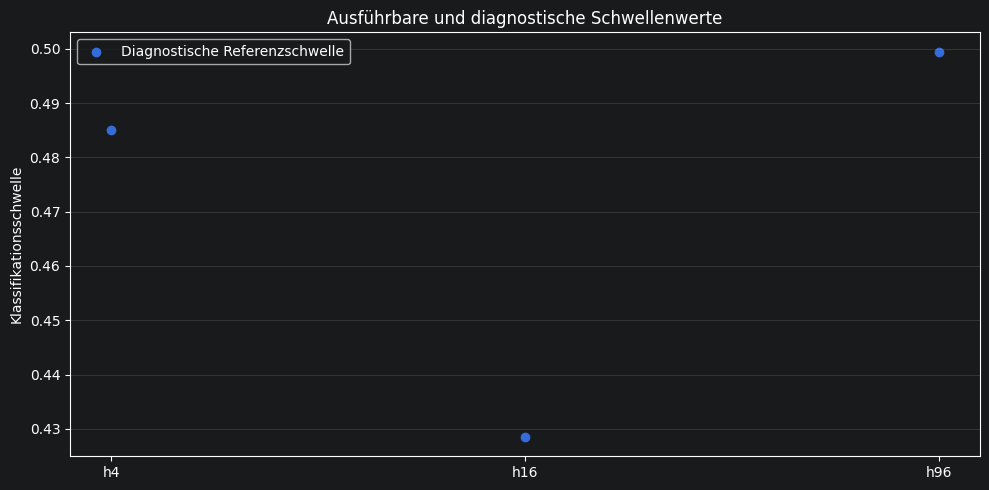

In [25]:
threshold_plot = threshold_table.sort_values("horizon").copy()
x = np.arange(len(threshold_plot))

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    x,
    threshold_plot["reference_threshold_diagnostic_only"],
    marker="o",
    label="Diagnostische Referenzschwelle",
)

executable_mask = threshold_plot[
    "recommended_threshold"
].notna()

if executable_mask.any():
    ax.scatter(
        x[executable_mask.to_numpy()],
        threshold_plot.loc[
            executable_mask,
            "recommended_threshold",
        ],
        marker="s",
        label="Ausführbare Schwelle",
    )

ax.set_xticks(x)
ax.set_xticklabels(
    [f"h{int(value)}" for value in threshold_plot["horizon"]]
)
ax.set_ylabel("Klassifikationsschwelle")
ax.set_title("Ausführbare und diagnostische Schwellenwerte")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Economic Gate

Das Economic Gate vergleicht handelbare Kandidaten mit der echten Alternative `No Trade`.

Typische Mindestbedingungen sind:

- ausreichender Anteil handelbarer Folds,
- ausreichender Anteil positiver Outer-Folds,
- Mindestanzahl von Trades,
- positiver gewichteter Netto-Return,
- positive gesamte Netto-Rendite,
- Profit Factor größer als 1,
- positiver Stabilitätsscore.

Ein Kandidat wird nur freigegeben, wenn **alle** geforderten Bedingungen erfüllt sind.

In [26]:
def economic_gate_payload_for_horizon(
    horizon: int,
) -> dict[str, Any]:
    path = economic_gate_paths.get(horizon)
    if path is not None:
        return read_json(path)

    threshold_payload = threshold_payloads.get(horizon, {})
    embedded = threshold_payload.get("economic_gate")
    return embedded if isinstance(embedded, dict) else {}


gate_rows: list[dict[str, Any]] = []

for horizon in available_horizons:
    payload = economic_gate_payload_for_horizon(horizon)
    checks = payload.get("checks")
    if not isinstance(checks, dict):
        checks = {}

    for check_name, check in checks.items():
        if not isinstance(check, dict):
            continue

        gate_rows.append(
            {
                "horizon": horizon,
                "check": check_name,
                "operator": check.get("operator"),
                "minimum": check.get("minimum"),
                "value": check.get("value"),
                "passed": bool(check.get("passed", False)),
            }
        )

economic_gate_table = pd.DataFrame(gate_rows)

for column in ("minimum", "value"):
    if column in economic_gate_table:
        economic_gate_table[column] = pd.to_numeric(
            economic_gate_table[column],
            errors="coerce",
        )

if economic_gate_table.empty:
    display(
        Markdown(
            "> Keine detaillierten Economic-Gate-Checks gefunden."
        )
    )
else:
    display(
        economic_gate_table.sort_values(
            ["horizon", "check"]
        ).reset_index(drop=True)
    )

,horizon,check,operator,minimum,value,passed
0,4,outer_combined_profit_factor,>,1.000000,0.000000,False
1,4,outer_stability_score,>,0.000000,0.000000,False
2,4,outer_total_net_return,>,0.000000,0.000000,False
3,4,outer_trade_count,>=,50.000000,0.000000,False
4,4,outer_weighted_net_return_mean,>,0.000000,0.000000,False
5,4,positive_outer_fold_ratio,>=,0.600000,0.000000,False
6,4,trade_fold_ratio,>=,0.600000,0.000000,False
7,16,outer_combined_profit_factor,>,1.000000,0.000000,False
8,16,outer_stability_score,>,0.000000,0.000000,False
9,16,outer_total_net_return,>,0.000000,0.000000,False


## 7. Economic-Gate-Matrix

Die Matrix zeigt je Horizont, welche Einzelbedingungen bestanden wurden.

- `1` bedeutet bestanden,
- `0` bedeutet nicht bestanden.

Die Gesamtentscheidung bleibt unabhängig davon in `threshold_table` dokumentiert.

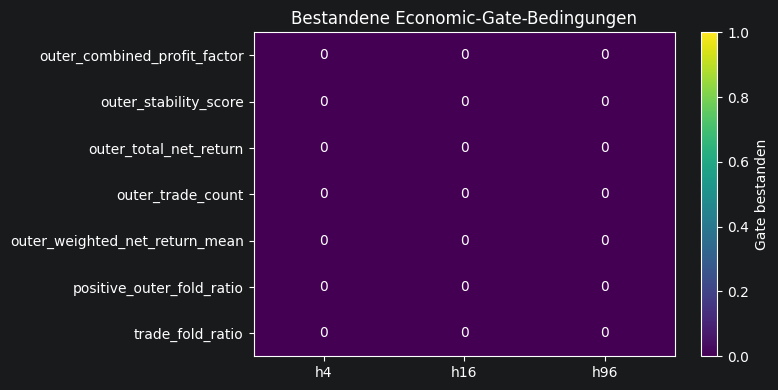

In [27]:
if not economic_gate_table.empty:
    gate_matrix = (
        economic_gate_table.pivot_table(
            index="check",
            columns="horizon",
            values="passed",
            aggfunc="first",
        )
        .fillna(False)
        .astype(int)
        .sort_index()
    )

    fig, ax = plt.subplots(
        figsize=(8, max(4, 0.55 * len(gate_matrix)))
    )
    image = ax.imshow(
        gate_matrix.to_numpy(),
        aspect="auto",
        vmin=0,
        vmax=1,
    )

    ax.set_xticks(
        np.arange(len(gate_matrix.columns))
    )
    ax.set_xticklabels(
        [f"h{int(value)}" for value in gate_matrix.columns]
    )
    ax.set_yticks(
        np.arange(len(gate_matrix.index))
    )
    ax.set_yticklabels(gate_matrix.index)
    ax.set_title("Bestandene Economic-Gate-Bedingungen")

    for row_index in range(gate_matrix.shape[0]):
        for column_index in range(gate_matrix.shape[1]):
            ax.text(
                column_index,
                row_index,
                str(gate_matrix.iat[row_index, column_index]),
                ha="center",
                va="center",
            )

    fig.colorbar(image, ax=ax, label="Gate bestanden")
    plt.tight_layout()
    plt.show()

## 8. Fold-Entscheidungen

Jeder äußere Walk-Forward-Fold darf `Trade` oder `No Trade` wählen.

Die robuste Gesamtfreigabe verlangt, dass ein ausreichender Anteil der Folds einen wirtschaftlich positiven Kandidaten auswählt. Einzelne positive Folds reichen nicht aus.

,horizon,fold,decision,is_trade
0,4,fold_01,no_trade,False
1,4,fold_02,no_trade,False
2,4,fold_03,no_trade,False
3,4,fold_04,no_trade,False
4,4,fold_05,no_trade,False
5,16,fold_01,no_trade,False
6,16,fold_02,no_trade,False
7,16,fold_03,no_trade,False
8,16,fold_04,no_trade,False
9,16,fold_05,no_trade,False


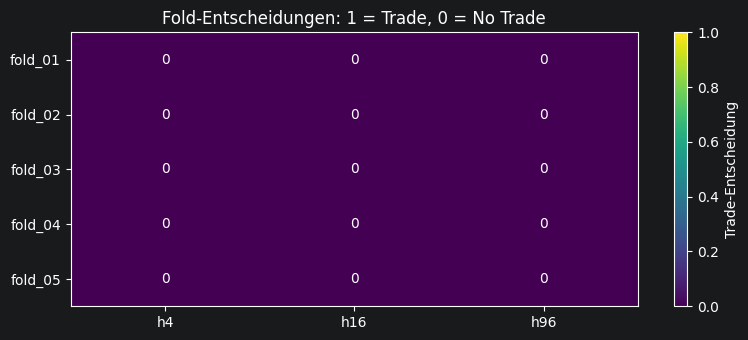

In [28]:
if fold_decision_table.empty:
    display(
        Markdown(
            "> Keine expliziten Fold-Entscheidungen gefunden."
        )
    )
else:
    display(
        fold_decision_table.sort_values(
            ["horizon", "fold"]
        ).reset_index(drop=True)
    )

    fold_matrix = (
        fold_decision_table.pivot_table(
            index="fold",
            columns="horizon",
            values="is_trade",
            aggfunc="first",
        )
        .fillna(False)
        .astype(int)
    )

    fig, ax = plt.subplots(
        figsize=(8, max(3.5, 0.65 * len(fold_matrix)))
    )
    image = ax.imshow(
        fold_matrix.to_numpy(),
        aspect="auto",
        vmin=0,
        vmax=1,
    )
    ax.set_xticks(np.arange(len(fold_matrix.columns)))
    ax.set_xticklabels(
        [f"h{int(value)}" for value in fold_matrix.columns]
    )
    ax.set_yticks(np.arange(len(fold_matrix.index)))
    ax.set_yticklabels(fold_matrix.index)
    ax.set_title("Fold-Entscheidungen: 1 = Trade, 0 = No Trade")

    for row_index in range(fold_matrix.shape[0]):
        for column_index in range(fold_matrix.shape[1]):
            ax.text(
                column_index,
                row_index,
                str(fold_matrix.iat[row_index, column_index]),
                ha="center",
                va="center",
            )

    fig.colorbar(image, ax=ax, label="Trade-Entscheidung")
    plt.tight_layout()
    plt.show()

## 9. Kostenmodell

Die gespeicherten Berichte enthalten das verwendete Kostenmodell.

Dokumentiert werden:

- Transaktionsgebührenparameter,
- Spread in Basispunkten,
- Slippage in Basispunkten,
- resultierende Round-Trip-Kosten.

Die Einzelparameter werden nicht neu interpretiert oder nachträglich verändert. Für die Freigabe ist der im Bericht gespeicherte Round-Trip-Gesamtwert maßgeblich.

In [29]:
cost_model_table = threshold_table[
    [
        "horizon",
        "transaction_fee_rate",
        "spread_basis_points",
        "slippage_basis_points",
        "round_trip_cost_rate",
        "round_trip_cost_basis_points",
        "cooldown_candles",
    ]
].sort_values("horizon")

display(cost_model_table)

,horizon,transaction_fee_rate,spread_basis_points,slippage_basis_points,round_trip_cost_rate,round_trip_cost_basis_points,cooldown_candles
0,4,0.001000,2.000000,5.000000,0.003197,31.974400,4
1,16,0.001000,2.000000,5.000000,0.003197,31.974400,16
2,96,0.001000,2.000000,5.000000,0.003197,31.974400,96


## 10. Strategy-Feasibility-Ergebnisse

Die Machbarkeitsanalyse untersucht gespeicherte Outer-Fold-Prognosen über mehrere:

- Schwellenwerte,
- Kostenstufen,
- Walk-Forward-Folds.

Sie ist eine **explorative Diagnostik**. Sie ersetzt keinen neuen Bestätigungslauf und keine finale Testauswertung.

In [30]:
feasibility_payloads: dict[int, dict[str, Any]] = {}
feasibility_rows: list[dict[str, Any]] = []

for horizon, path in sorted(feasibility_paths.items()):
    payload = read_json(path)
    feasibility_payloads[horizon] = payload

    current_cost = first_present(
        payload,
        "current_cost_basis_points",
        "current_round_trip_cost_basis_points",
    )

    classification = first_present(
        payload,
        "feasibility_classification",
        "classification",
    )

    decision = first_present(
        payload,
        "source_decision",
        "threshold_decision",
        default=threshold_payloads.get(
            horizon,
            {},
        ).get("decision"),
    )

    feasibility_rows.append(
        {
            "horizon": horizon,
            "horizon_hours": horizon * 0.25,
            "model": first_present(payload, "model"),
            "calibration_method": first_present(
                payload,
                "calibration_method",
            ),
            "source_decision": decision,
            "any_robust_region": bool(
                first_present(
                    payload,
                    "any_robust_region",
                    default=False,
                )
            ),
            "zero_cost_feasible": bool(
                first_present(
                    payload,
                    "zero_cost_feasible",
                    default=False,
                )
            ),
            "maximum_robust_cost_basis_points": first_present(
                payload,
                "maximum_robust_cost_basis_points",
            ),
            "current_cost_basis_points": current_cost,
            "current_cost_feasible": bool(
                first_present(
                    payload,
                    "current_cost_feasible",
                    default=False,
                )
            ),
            "feasibility_classification": classification,
            "final_evaluation_allowed": bool(
                first_present(
                    payload,
                    "final_evaluation_allowed",
                    default=False,
                )
            ),
            "source_path": str(path),
        }
    )

feasibility_table = pd.DataFrame(feasibility_rows)

for column in (
    "maximum_robust_cost_basis_points",
    "current_cost_basis_points",
):
    if column in feasibility_table:
        feasibility_table[column] = pd.to_numeric(
            feasibility_table[column],
            errors="coerce",
        )

display(feasibility_table.sort_values("horizon"))

,horizon,horizon_hours,model,calibration_method,source_decision,any_robust_region,zero_cost_feasible,maximum_robust_cost_basis_points,current_cost_basis_points,current_cost_feasible,feasibility_classification,final_evaluation_allowed,source_path
0,16,4.000000,None,None,no_trade,True,True,10.000000,31.974400,False,signal_exists_but_is_cost_limited,False,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/feasibility/feasibility_decision.json
1,96,24.000000,None,None,no_trade,True,True,5.000000,31.974400,False,signal_exists_but_is_cost_limited,False,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/feasibility/feasibility_decision.json


## 11. Maximale robuste Kosten nach Horizont

Die maximal robuste Kostenstufe ist die höchste untersuchte Kostenstufe, bei der die vorgegebenen Robustheitsbedingungen noch erfüllt waren.

Sie wird der realistischen aktuellen Round-Trip-Kostenannahme gegenübergestellt.

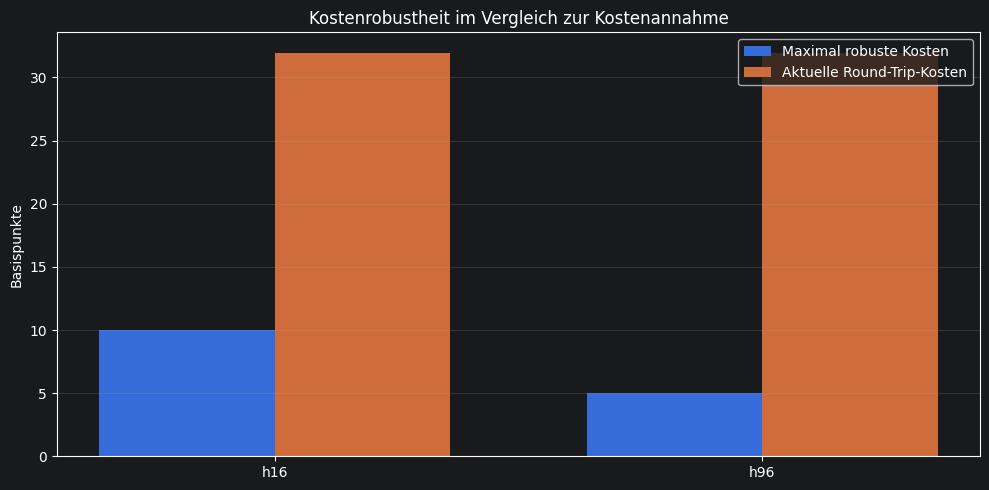

In [31]:
robust_plot = feasibility_table.dropna(
    subset=[
        "maximum_robust_cost_basis_points",
        "current_cost_basis_points",
    ]
).sort_values("horizon")

if robust_plot.empty:
    display(
        Markdown(
            "> Keine vollständigen Kostenrobustheitswerte gefunden."
        )
    )
else:
    x = np.arange(len(robust_plot))
    width = 0.36

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(
        x - width / 2,
        robust_plot["maximum_robust_cost_basis_points"],
        width=width,
        label="Maximal robuste Kosten",
    )
    ax.bar(
        x + width / 2,
        robust_plot["current_cost_basis_points"],
        width=width,
        label="Aktuelle Round-Trip-Kosten",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"h{int(value)}" for value in robust_plot["horizon"]]
    )
    ax.set_ylabel("Basispunkte")
    ax.set_title("Kostenrobustheit im Vergleich zur Kostenannahme")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 12. Deckungsgrad der aktuellen Kosten

Der Deckungsgrad ist eine rein deskriptive Kennzahl:

```text
maximal robuste Kosten / aktuelle Kosten
```

Ein Wert unter 1 bedeutet, dass das explorative Signal die angenommene Kostenbelastung nicht vollständig abdeckt.

,horizon,maximum_robust_cost_basis_points,current_cost_basis_points,cost_coverage_ratio,uncovered_cost_basis_points,current_cost_feasible
0,16,10.000000,31.974400,0.312750,21.974400,False
1,96,5.000000,31.974400,0.156375,26.974400,False


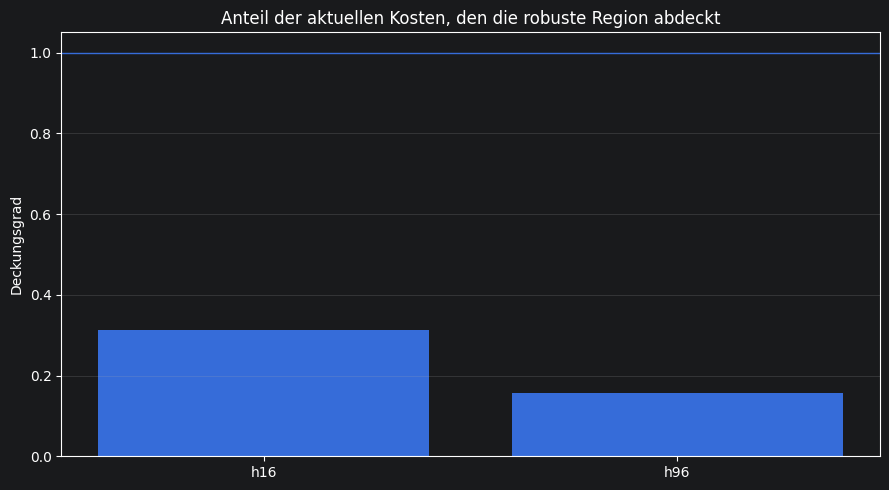

In [32]:
coverage_table = feasibility_table.copy()
coverage_table["cost_coverage_ratio"] = (
    coverage_table["maximum_robust_cost_basis_points"]
    / coverage_table["current_cost_basis_points"]
)
coverage_table["uncovered_cost_basis_points"] = (
    coverage_table["current_cost_basis_points"]
    - coverage_table["maximum_robust_cost_basis_points"]
)

display(
    coverage_table[
        [
            "horizon",
            "maximum_robust_cost_basis_points",
            "current_cost_basis_points",
            "cost_coverage_ratio",
            "uncovered_cost_basis_points",
            "current_cost_feasible",
        ]
    ].sort_values("horizon")
)

coverage_plot = coverage_table.dropna(
    subset=["cost_coverage_ratio"]
).sort_values("horizon")

if not coverage_plot.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(
        [
            f"h{int(value)}"
            for value in coverage_plot["horizon"]
        ],
        coverage_plot["cost_coverage_ratio"],
    )
    ax.axhline(1.0, linewidth=1)
    ax.set_ylabel("Deckungsgrad")
    ax.set_title(
        "Anteil der aktuellen Kosten, den die robuste Region abdeckt"
    )
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 13. Kosten-Schwellen-Flächen laden

Bevorzugt werden die in `feasibility_decision.json` referenzierten Dateien:

```text
best_threshold_by_cost.csv
aggregate_cost_threshold_surface.csv
fold_cost_threshold_surface.csv
```

Diese Daten werden nur visualisiert. Es erfolgt keine neue Schwellenwertauswahl.

In [33]:
def report_path_from_payload(
    payload: dict[str, Any],
    *keys: str,
) -> Path | None:
    report_paths = payload.get("report_paths")
    if isinstance(report_paths, dict):
        for key in keys:
            value = report_paths.get(key)
            if isinstance(value, str):
                existing = normalize_existing_path(value)
                if existing is not None:
                    return existing
    return None


best_by_cost_frames: list[pd.DataFrame] = []
aggregate_surface_frames: list[pd.DataFrame] = []
fold_surface_frames: list[pd.DataFrame] = []

for horizon, payload in feasibility_payloads.items():
    source_path = feasibility_paths[horizon]
    parent = source_path.parent

    best_path = report_path_from_payload(
        payload,
        "best_threshold_by_cost",
    )
    if best_path is None:
        fallback = parent / "best_threshold_by_cost.csv"
        best_path = fallback if fallback.exists() else None

    aggregate_path = report_path_from_payload(
        payload,
        "aggregate_cost_threshold_surface",
    )
    if aggregate_path is None:
        fallback = (
            parent / "aggregate_cost_threshold_surface.csv"
        )
        aggregate_path = (
            fallback if fallback.exists() else None
        )

    fold_path = report_path_from_payload(
        payload,
        "fold_cost_threshold_surface",
    )
    if fold_path is None:
        fallback = parent / "fold_cost_threshold_surface.csv"
        fold_path = fallback if fallback.exists() else None

    for path, target in (
        (best_path, best_by_cost_frames),
        (aggregate_path, aggregate_surface_frames),
        (fold_path, fold_surface_frames),
    ):
        frame = read_csv_optional(path)
        if frame.empty:
            continue
        frame = frame.copy()
        frame["horizon"] = horizon
        frame["source_path"] = str(path)
        target.append(frame)

best_threshold_by_cost = (
    pd.concat(best_by_cost_frames, ignore_index=True)
    if best_by_cost_frames
    else pd.DataFrame()
)
aggregate_cost_surface = (
    pd.concat(aggregate_surface_frames, ignore_index=True)
    if aggregate_surface_frames
    else pd.DataFrame()
)
fold_cost_surface = (
    pd.concat(fold_surface_frames, ignore_index=True)
    if fold_surface_frames
    else pd.DataFrame()
)

print(
    "Best-by-cost rows:",
    len(best_threshold_by_cost),
)
print(
    "Aggregate-surface rows:",
    len(aggregate_cost_surface),
)
print(
    "Fold-surface rows:",
    len(fold_cost_surface),
)

Best-by-cost rows: 12
Aggregate-surface rows: 1140
Fold-surface rows: 5700


## 14. Beste diagnostische Kennzahl nach Kostenstufe

Die Spaltennamen können je Modulversion leicht variieren. Das Notebook erkennt geeignete Spalten für:

- Kostenstufe,
- Schwellenwert,
- Stabilitäts- oder Netto-Return-Kennzahl.

Die Darstellung ist rein diagnostisch.

,round_trip_cost_basis_points,decision,threshold,robust_region_passed,stability_score,weighted_net_return_mean,total_net_return,combined_profit_factor,positive_fold_ratio,gate_fold_ratio,total_trades,combined_break_even_cost_basis_points,horizon,source_path
0,0.000000,robust_region,0.520000,True,0.001360,0.002778,0.413971,2.895149,0.800000,0.600000,149,27.706318,16,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/feasibility/best_threshold_by_cost.csv
1,5.000000,robust_region,0.520000,True,0.000859,0.002277,0.339264,2.402797,0.800000,0.600000,149,27.706318,16,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/feasibility/best_threshold_by_cost.csv
2,10.000000,robust_region,0.520000,True,0.000359,0.001776,0.264557,1.989214,0.800000,0.600000,149,27.706318,16,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/feasibility/best_threshold_by_cost.csv
3,20.000000,diagnostic_best_only,0.560000,False,0.001255,0.004136,0.090990,5.510687,0.600000,0.000000,22,61.106260,16,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/feasibility/best_threshold_by_cost.csv
4,31.974400,diagnostic_best_only,0.585000,False,0.000342,0.003146,0.031460,8.152162,0.400000,0.000000,10,63.235734,16,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/feasibility/best_threshold_by_cost.csv
5,40.000000,diagnostic_best_only,0.595000,False,0.000125,0.004240,0.029679,8.193502,0.200000,0.000000,7,82.050185,16,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/feasibility/best_threshold_by_cost.csv
6,0.000000,robust_region,0.504469,True,0.000563,0.002859,0.792046,1.644090,0.600000,0.600000,277,28.512178,96,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/feasibility/best_threshold_by_cost.csv
7,5.000000,robust_region,0.504469,True,0.000062,0.002358,0.653150,1.504874,0.600000,0.600000,277,28.512178,96,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/feasibility/best_threshold_by_cost.csv
8,10.000000,diagnostic_best_only,0.650000,False,0.000745,0.017487,0.069947,inf,0.200000,0.000000,4,181.691067,96,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/feasibility/best_threshold_by_cost.csv
9,20.000000,diagnostic_best_only,0.650000,False,0.000656,0.016468,0.065873,66.891527,0.200000,0.000000,4,181.691067,96,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/feasibility/best_threshold_by_cost.csv


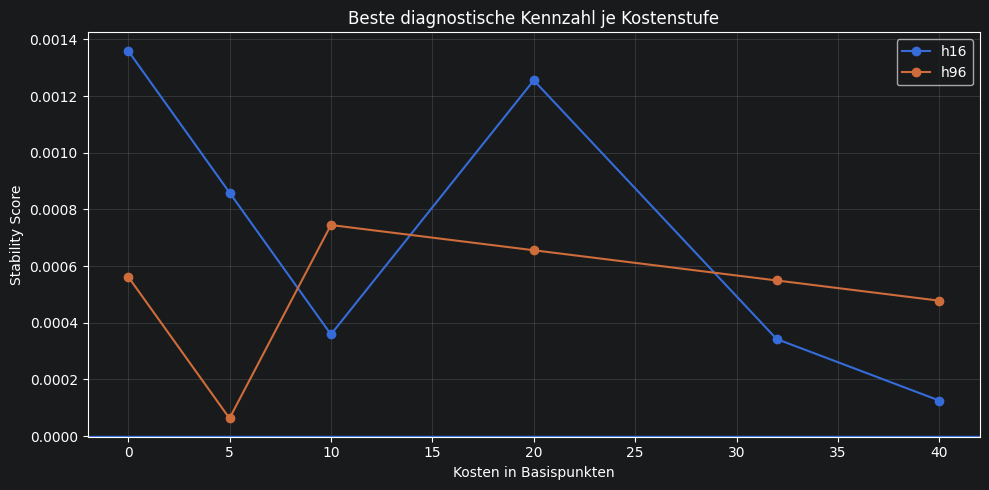

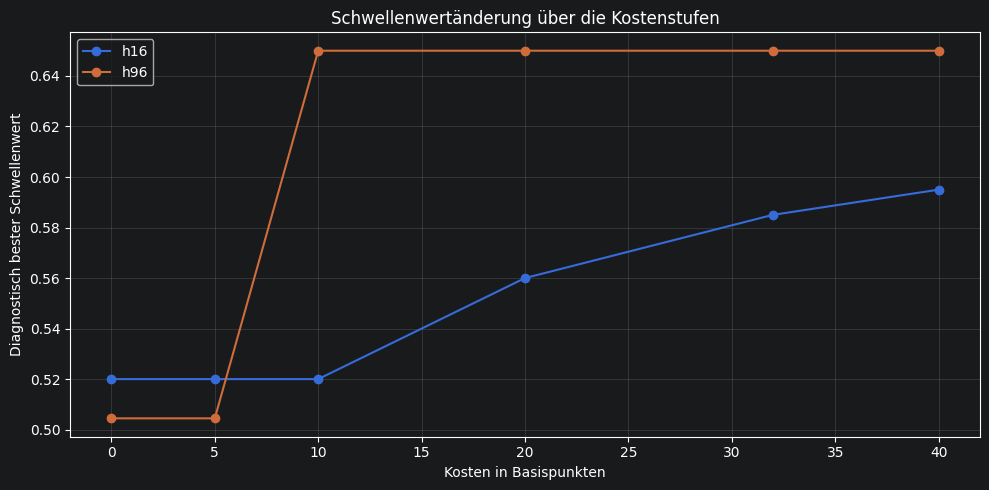

In [34]:
def first_existing_column(
    frame: pd.DataFrame,
    candidates: Iterable[str],
) -> str | None:
    for candidate in candidates:
        if candidate in frame.columns:
            return candidate
    return None


if best_threshold_by_cost.empty:
    display(
        Markdown(
            "> Keine `best_threshold_by_cost.csv` gefunden."
        )
    )
else:
    cost_column = first_existing_column(
        best_threshold_by_cost,
        (
            "cost_basis_points",
            "round_trip_cost_basis_points",
            "total_cost_basis_points",
            "transaction_cost_basis_points",
        ),
    )
    metric_column = first_existing_column(
        best_threshold_by_cost,
        (
            "stability_score",
            "objective",
            "net_return_lcb",
            "weighted_net_return_mean",
            "mean_net_return",
            "outer_stability_score",
        ),
    )
    threshold_column = first_existing_column(
        best_threshold_by_cost,
        (
            "threshold",
            "best_threshold",
            "reference_threshold",
        ),
    )

    display(best_threshold_by_cost.head(30))

    if cost_column and metric_column:
        plot_frame = best_threshold_by_cost.copy()
        plot_frame[cost_column] = pd.to_numeric(
            plot_frame[cost_column],
            errors="coerce",
        )
        plot_frame[metric_column] = pd.to_numeric(
            plot_frame[metric_column],
            errors="coerce",
        )
        plot_frame = plot_frame.dropna(
            subset=[cost_column, metric_column]
        )

        fig, ax = plt.subplots(figsize=(10, 5))
        for horizon, group in plot_frame.groupby(
            "horizon"
        ):
            group = group.sort_values(cost_column)
            ax.plot(
                group[cost_column],
                group[metric_column],
                marker="o",
                label=f"h{int(horizon)}",
            )

        ax.axhline(0.0, linewidth=1)
        ax.set_xlabel("Kosten in Basispunkten")
        ax.set_ylabel(metric_column.replace("_", " ").title())
        ax.set_title(
            "Beste diagnostische Kennzahl je Kostenstufe"
        )
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

    if cost_column and threshold_column:
        threshold_cost_plot = best_threshold_by_cost.copy()
        threshold_cost_plot[cost_column] = pd.to_numeric(
            threshold_cost_plot[cost_column],
            errors="coerce",
        )
        threshold_cost_plot[threshold_column] = pd.to_numeric(
            threshold_cost_plot[threshold_column],
            errors="coerce",
        )
        threshold_cost_plot = threshold_cost_plot.dropna(
            subset=[cost_column, threshold_column]
        )

        fig, ax = plt.subplots(figsize=(10, 5))
        for horizon, group in threshold_cost_plot.groupby(
            "horizon"
        ):
            group = group.sort_values(cost_column)
            ax.plot(
                group[cost_column],
                group[threshold_column],
                marker="o",
                label=f"h{int(horizon)}",
            )

        ax.set_xlabel("Kosten in Basispunkten")
        ax.set_ylabel("Diagnostisch bester Schwellenwert")
        ax.set_title(
            "Schwellenwertänderung über die Kostenstufen"
        )
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

## 15. Kosten-Schwellen-Oberfläche

Wenn die aggregierte Oberfläche geeignete Spalten enthält, wird je Horizont eine Heatmap dargestellt.

Die Heatmap ist keine neue Optimierung. Sie visualisiert nur bereits gespeicherte Ergebnisse.

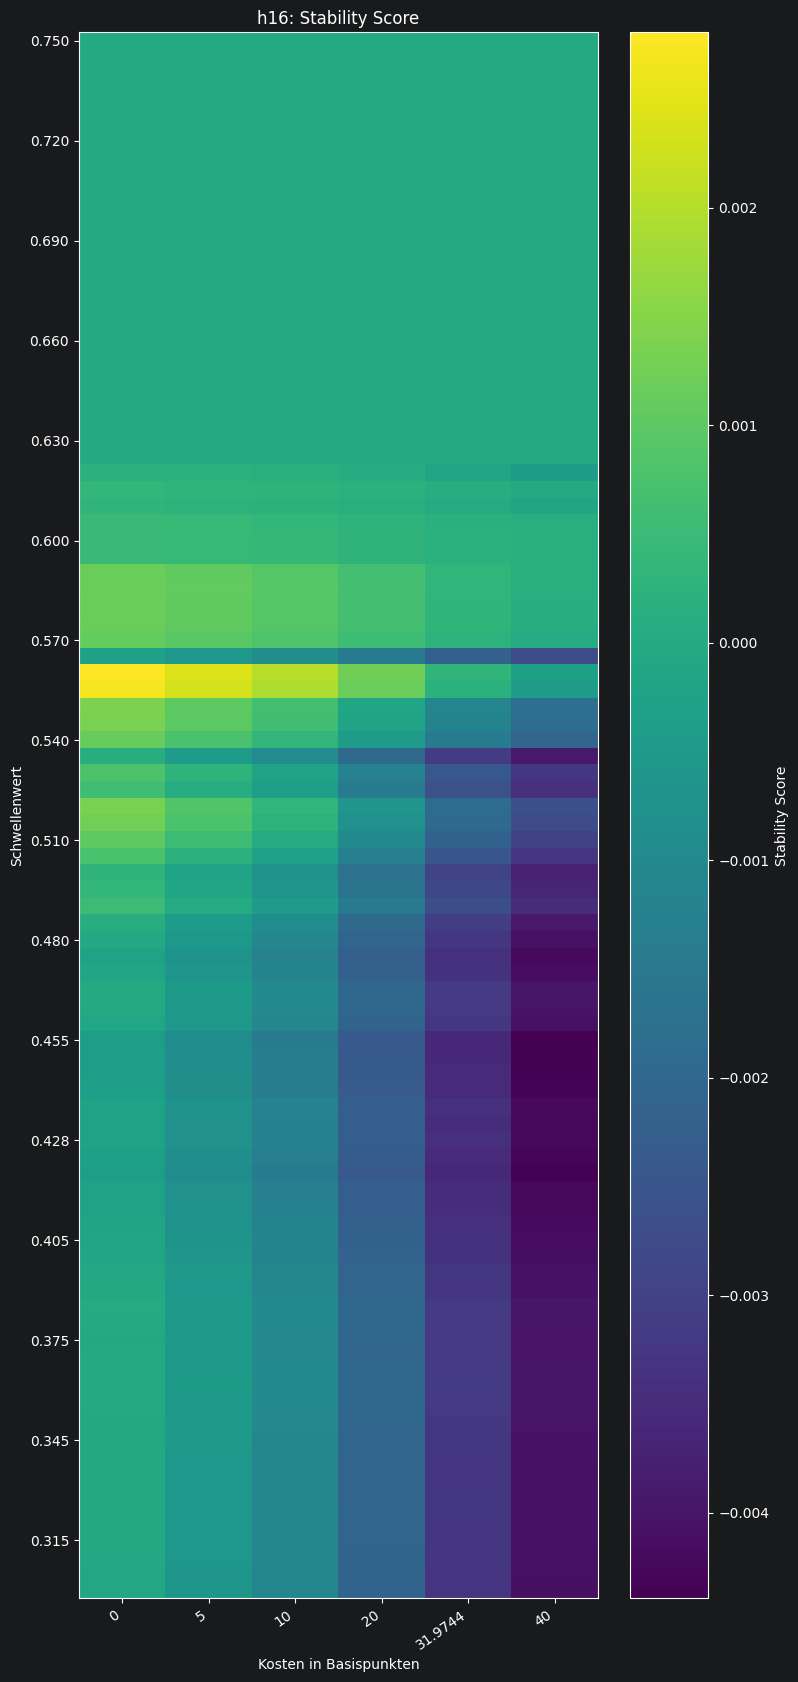

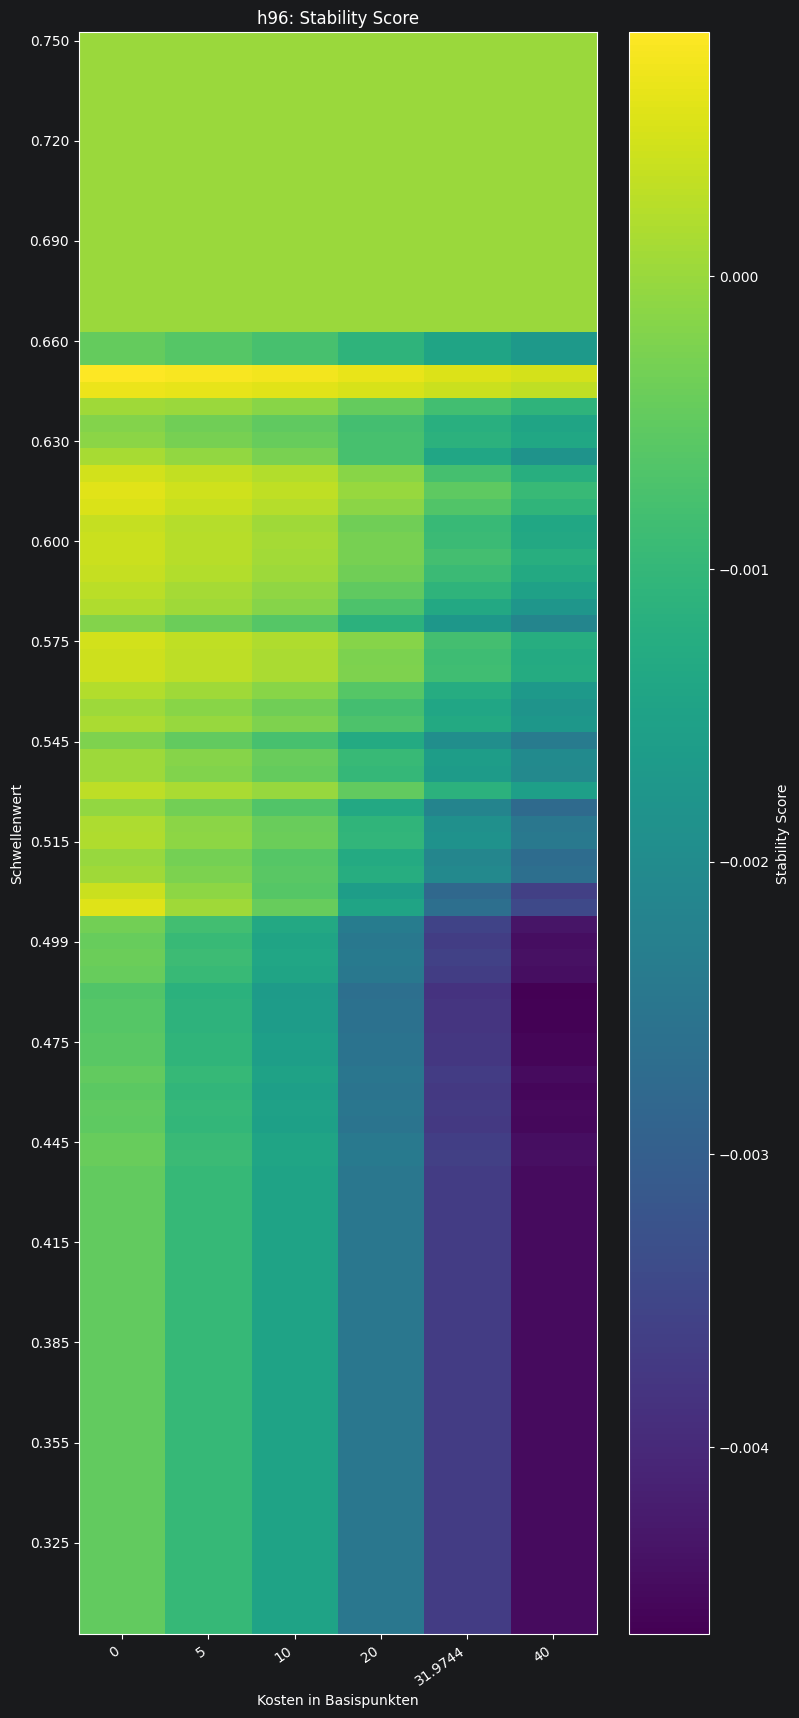

In [35]:
if aggregate_cost_surface.empty:
    display(
        Markdown(
            "> Keine aggregierte Kosten-Schwellen-Oberfläche gefunden."
        )
    )
else:
    cost_column = first_existing_column(
        aggregate_cost_surface,
        (
            "cost_basis_points",
            "round_trip_cost_basis_points",
            "total_cost_basis_points",
            "transaction_cost_basis_points",
        ),
    )
    threshold_column = first_existing_column(
        aggregate_cost_surface,
        (
            "threshold",
            "candidate_threshold",
        ),
    )
    metric_column = first_existing_column(
        aggregate_cost_surface,
        (
            "stability_score",
            "objective",
            "net_return_lcb",
            "weighted_net_return_mean",
            "mean_net_return",
            "outer_stability_score",
        ),
    )

    if not all(
        (cost_column, threshold_column, metric_column)
    ):
        display(
            Markdown(
                "> Die Oberfläche wurde gefunden, aber die "
                "benötigten Spalten konnten nicht eindeutig "
                "identifiziert werden."
            )
        )
        display(aggregate_cost_surface.head(30))
    else:
        for horizon, group in aggregate_cost_surface.groupby(
            "horizon"
        ):
            prepared = group.copy()
            for column in (
                cost_column,
                threshold_column,
                metric_column,
            ):
                prepared[column] = pd.to_numeric(
                    prepared[column],
                    errors="coerce",
                )
            prepared = prepared.dropna(
                subset=[
                    cost_column,
                    threshold_column,
                    metric_column,
                ]
            )

            pivot = prepared.pivot_table(
                index=threshold_column,
                columns=cost_column,
                values=metric_column,
                aggfunc="mean",
            ).sort_index(ascending=False)

            if pivot.empty:
                continue

            fig, ax = plt.subplots(
                figsize=(
                    max(8, 0.8 * len(pivot.columns)),
                    max(5, 0.18 * len(pivot.index)),
                )
            )
            image = ax.imshow(
                pivot.to_numpy(),
                aspect="auto",
            )
            ax.set_xticks(
                np.arange(len(pivot.columns))
            )
            ax.set_xticklabels(
                [
                    f"{float(value):g}"
                    for value in pivot.columns
                ],
                rotation=35,
                ha="right",
            )

            y_step = max(1, len(pivot.index) // 15)
            y_positions = np.arange(
                0,
                len(pivot.index),
                y_step,
            )
            ax.set_yticks(y_positions)
            ax.set_yticklabels(
                [
                    f"{float(pivot.index[position]):.3f}"
                    for position in y_positions
                ]
            )

            ax.set_xlabel("Kosten in Basispunkten")
            ax.set_ylabel("Schwellenwert")
            ax.set_title(
                f"h{int(horizon)}: "
                + metric_column.replace("_", " ").title()
            )
            fig.colorbar(
                image,
                ax=ax,
                label=metric_column.replace("_", " ").title(),
            )
            plt.tight_layout()
            plt.show()

## 16. Rejection Reasons

Die gespeicherten Ablehnungsgründe zeigen, warum selbst der jeweils beste handelbare Kandidat gegenüber `No Trade` nicht freigegeben wurde.

Sie sind ein wesentlicher Bestandteil der fachlichen Nachvollziehbarkeit.

In [36]:
if rejection_table.empty:
    display(
        Markdown(
            "> Keine expliziten Ablehnungsgründe gefunden."
        )
    )
else:
    for horizon, group in rejection_table.groupby(
        "horizon",
        sort=True,
    ):
        lines = "\n".join(
            f"- {reason}"
            for reason in group["reason"].tolist()
        )
        display(
            Markdown(
                f"### h{int(horizon)}\n\n{lines}"
            )
        )

### h4

- trade_fold_ratio: Wert 0.0 erfüllt >= 0.6 nicht.
- positive_outer_fold_ratio: Wert 0.0 erfüllt >= 0.6 nicht.
- outer_trade_count: Wert 0 erfüllt >= 50 nicht.
- outer_weighted_net_return_mean: Wert 0.0 erfüllt > 0.0 nicht.
- outer_total_net_return: Wert 0.0 erfüllt > 0.0 nicht.
- outer_combined_profit_factor: Wert 0.0 erfüllt > 1.0 nicht.
- outer_stability_score: Wert 0.0 erfüllt > 0.0 nicht.

### h16

- trade_fold_ratio: Wert 0.0 erfüllt >= 0.6 nicht.
- positive_outer_fold_ratio: Wert 0.0 erfüllt >= 0.6 nicht.
- outer_trade_count: Wert 0 erfüllt >= 40 nicht.
- outer_weighted_net_return_mean: Wert 0.0 erfüllt > 0.0 nicht.
- outer_total_net_return: Wert 0.0 erfüllt > 0.0 nicht.
- outer_combined_profit_factor: Wert 0.0 erfüllt > 1.0 nicht.
- outer_stability_score: Wert 0.0 erfüllt > 0.0 nicht.

### h96

- trade_fold_ratio: Wert 0.0 erfüllt >= 0.6 nicht.
- positive_outer_fold_ratio: Wert 0.0 erfüllt >= 0.6 nicht.
- outer_trade_count: Wert 0 erfüllt >= 40 nicht.
- outer_weighted_net_return_mean: Wert 0.0 erfüllt > 0.0 nicht.
- outer_total_net_return: Wert 0.0 erfüllt > 0.0 nicht.
- outer_combined_profit_factor: Wert 0.0 erfüllt > 1.0 nicht.
- outer_stability_score: Wert 0.0 erfüllt > 0.0 nicht.

## 17. Gemeinsame Abschlussbewertung

Die finale Übersicht verbindet:

- Threshold-Entscheidung,
- Economic Gate,
- Kostenrobustheit,
- aktuelle Kostentragfähigkeit,
- Freigabestatus.

Der explorativ stärkste Horizont ist derjenige mit der höchsten maximal robusten Kostenstufe. Das ist keine Produktionsfreigabe.

In [37]:
final_economic_table = threshold_table.merge(
    feasibility_table[
        [
            "horizon",
            "any_robust_region",
            "zero_cost_feasible",
            "maximum_robust_cost_basis_points",
            "current_cost_basis_points",
            "current_cost_feasible",
            "feasibility_classification",
        ]
    ],
    on="horizon",
    how="outer",
    suffixes=("_threshold", "_feasibility"),
)

final_economic_table["confirmatory_run_allowed"] = (
    final_economic_table["economic_gate_passed"].fillna(False)
    & final_economic_table["current_cost_feasible"].fillna(False)
)

display(
    final_economic_table[
        [
            "horizon",
            "model",
            "calibration_method",
            "decision",
            "economic_gate_passed",
            "maximum_robust_cost_basis_points",
            "current_cost_basis_points",
            "current_cost_feasible",
            "feasibility_classification",
            "confirmatory_run_allowed",
        ]
    ].sort_values("horizon")
)

eligible = final_economic_table.dropna(
    subset=["maximum_robust_cost_basis_points"]
)

best_exploratory_horizon = (
    int(
        eligible.sort_values(
            [
                "maximum_robust_cost_basis_points",
                "horizon",
            ],
            ascending=[False, True],
        ).iloc[0]["horizon"]
    )
    if not eligible.empty
    else None
)

overall_decision = (
    "confirmatory_run_required"
    if final_economic_table[
        "confirmatory_run_allowed"
    ].fillna(False).any()
    else "no_trade"
)

print(
    "Explorativ stärkster Horizont:",
    (
        f"h{best_exploratory_horizon}"
        if best_exploratory_horizon is not None
        else "nicht bestimmbar"
    ),
)
print("Gesamtentscheidung:", overall_decision)

,horizon,model,calibration_method,decision,economic_gate_passed,maximum_robust_cost_basis_points,current_cost_basis_points,current_cost_feasible,feasibility_classification,confirmatory_run_allowed
0,4,lightgbm,sigmoid,no_trade,False,NaN,NaN,NaN,NaN,False
1,16,catboost,sigmoid,no_trade,False,10.000000,31.974400,False,signal_exists_but_is_cost_limited,False
2,96,lightgbm,raw,no_trade,False,5.000000,31.974400,False,signal_exists_but_is_cost_limited,False


Explorativ stärkster Horizont: h16
Gesamtentscheidung: no_trade


## 18. Fachliche Interpretation

Die Schlussfolgerung muss eng auf die untersuchte Pipeline begrenzt bleiben.

Nicht zulässig wäre:

> Bitcoin ist grundsätzlich nicht vorhersagbar.

Fachlich korrekt ist:

> Mit den verwendeten BTCUSDT-Spotdaten, Features, Horizonten, Modellen und Kostenannahmen wurde kein Kandidat gefunden, der das vorab definierte Economic Gate unter realistischen Kosten bestand.

In [38]:
interpretation_lines: list[str] = []

for row in final_economic_table.sort_values(
    "horizon"
).itertuples():
    horizon = int(row.horizon)
    decision = getattr(row, "decision", "unknown")
    robust_cost = getattr(
        row,
        "maximum_robust_cost_basis_points",
        np.nan,
    )
    current_cost = getattr(
        row,
        "current_cost_basis_points",
        np.nan,
    )
    feasible = bool(
        getattr(row, "current_cost_feasible", False)
    )

    line = (
        f"- **h{horizon} ({horizon * 15 / 60:g} Stunden):** "
        f"Entscheidung `{decision}`"
    )
    if pd.notna(robust_cost):
        line += (
            f", maximal robuste Kosten "
            f"{robust_cost:.4f} bp"
        )
    if pd.notna(current_cost):
        line += (
            f", aktuelle Kostenannahme "
            f"{current_cost:.4f} bp"
        )
    line += (
        ", bei aktuellen Kosten tragfähig."
        if feasible
        else ", bei aktuellen Kosten nicht tragfähig."
    )
    interpretation_lines.append(line)

closing = (
    "Kein Horizont wurde für einen Bestätigungslauf freigegeben. "
    "Der finale Test bleibt geschlossen."
    if overall_decision == "no_trade"
    else (
        "Mindestens ein Horizont erfüllt die Bedingungen für einen "
        "separat vorab spezifizierten Bestätigungslauf. "
        "Dieses Notebook öffnet den finalen Test dennoch nicht."
    )
)

display(
    Markdown(
        "### Ergebnis je Horizont\n\n"
        + "\n".join(interpretation_lines)
        + "\n\n### Gesamtfazit\n\n"
        + closing
    )
)

### Ergebnis je Horizont

- **h4 (1 Stunden):** Entscheidung `no_trade`, bei aktuellen Kosten tragfähig.
- **h16 (4 Stunden):** Entscheidung `no_trade`, maximal robuste Kosten 10.0000 bp, aktuelle Kostenannahme 31.9744 bp, bei aktuellen Kosten nicht tragfähig.
- **h96 (24 Stunden):** Entscheidung `no_trade`, maximal robuste Kosten 5.0000 bp, aktuelle Kostenannahme 31.9744 bp, bei aktuellen Kosten nicht tragfähig.

### Gesamtfazit

Kein Horizont wurde für einen Bestätigungslauf freigegeben. Der finale Test bleibt geschlossen.

## 19. Abgeleitete Tabellen exportieren

Die deskriptiven Ergebnisse werden für Notebook 10 und den Abschlussbericht gespeichert:

```text
reports/final/notebook_09/
├── threshold_decisions.csv
├── economic_gate_checks.csv
├── fold_decisions.csv
├── feasibility_comparison.csv
├── economic_summary.csv
├── cost_surface_combined.csv
└── notebook_09_summary.json
```

Die ursprünglichen Threshold- und Feasibility-Berichte werden nicht verändert.

In [39]:
NOTEBOOK_REPORT_DIR = (
    FINAL_REPORT_DIR / "notebook_09"
)
NOTEBOOK_REPORT_DIR.mkdir(parents=True, exist_ok=True)

threshold_export = (
    NOTEBOOK_REPORT_DIR / "threshold_decisions.csv"
)
gate_export = (
    NOTEBOOK_REPORT_DIR / "economic_gate_checks.csv"
)
fold_export = (
    NOTEBOOK_REPORT_DIR / "fold_decisions.csv"
)
feasibility_export = (
    NOTEBOOK_REPORT_DIR / "feasibility_comparison.csv"
)
economic_export = (
    NOTEBOOK_REPORT_DIR / "economic_summary.csv"
)
surface_export = (
    NOTEBOOK_REPORT_DIR / "cost_surface_combined.csv"
)
summary_export = (
    NOTEBOOK_REPORT_DIR / "notebook_09_summary.json"
)

threshold_table.to_csv(threshold_export, index=False)
economic_gate_table.to_csv(gate_export, index=False)
fold_decision_table.to_csv(fold_export, index=False)
feasibility_table.to_csv(
    feasibility_export,
    index=False,
)
final_economic_table.to_csv(
    economic_export,
    index=False,
)

if not aggregate_cost_surface.empty:
    aggregate_cost_surface.to_csv(
        surface_export,
        index=False,
    )
else:
    pd.DataFrame().to_csv(surface_export, index=False)

summary_payload = {
    "notebook": "09_threshold_and_strategy_feasibility",
    "project_root": str(PROJECT_ROOT),
    "available_horizons": [
        int(value) for value in available_horizons
    ],
    "expected_horizons": list(EXPECTED_HORIZONS),
    "missing_expected_horizons": missing_expected,
    "overall_decision": overall_decision,
    "best_exploratory_horizon": (
        best_exploratory_horizon
    ),
    "final_test_accessed": False,
    "new_threshold_optimization_performed": False,
    "new_backtest_performed": False,
    "new_training_performed": False,
    "results": (
        final_economic_table.replace(
            {np.nan: None}
        ).to_dict(orient="records")
    ),
    "outputs": {
        "threshold_decisions": str(threshold_export),
        "economic_gate_checks": str(gate_export),
        "fold_decisions": str(fold_export),
        "feasibility_comparison": str(
            feasibility_export
        ),
        "economic_summary": str(economic_export),
        "cost_surface_combined": str(
            surface_export
        ),
    },
}

with summary_export.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        summary_payload,
        handle,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

for path in (
    threshold_export,
    gate_export,
    fold_export,
    feasibility_export,
    economic_export,
    surface_export,
    summary_export,
):
    print(f"- {path}")

- /home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/notebook_09/threshold_decisions.csv
- /home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/notebook_09/economic_gate_checks.csv
- /home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/notebook_09/fold_decisions.csv
- /home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/notebook_09/feasibility_comparison.csv
- /home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/notebook_09/economic_summary.csv
- /home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/notebook_09/cost_surface_combined.csv
- /home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/notebook_09/notebook_09_summary.json


## 20. Definition of Done für Notebook 09

Notebook 09 ist abgeschlossen, wenn:

- Threshold-Berichte erkannt wurden,
- Economic-Gate-Entscheidungen dokumentiert sind,
- Fold-Entscheidungen ausgewertet wurden,
- das Kostenmodell sichtbar ist,
- Feasibility-Berichte eingelesen wurden,
- maximale robuste Kosten je Horizont verglichen wurden,
- diagnostische Kostenoberflächen dargestellt wurden, sofern vorhanden,
- `No Trade` als echte Alternative berücksichtigt wurde,
- kein neuer Threshold optimiert wurde,
- kein neues Backtesting ausgeführt wurde,
- der finale Test unangetastet blieb,
- die abgeleiteten Tabellen für Notebook 10 exportiert wurden.

In [40]:
definition_of_done = {
    "threshold_artifacts_found": bool(threshold_paths),
    "threshold_table_not_empty": not threshold_table.empty,
    "feasibility_artifacts_found": bool(
        feasibility_paths
    ),
    "feasibility_table_not_empty": (
        not feasibility_table.empty
    ),
    "economic_summary_created": (
        not final_economic_table.empty
    ),
    "test_not_used_for_selection": (
        not threshold_table[
            "test_used_for_selection"
        ].fillna(False).any()
        if not threshold_table.empty
        else False
    ),
    "holdout_not_used_for_threshold_selection": (
        not threshold_table[
            "holdout_used_for_selection"
        ].fillna(False).any()
        if not threshold_table.empty
        else False
    ),
    "new_threshold_optimization_performed": False,
    "new_backtest_performed": False,
    "new_training_performed": False,
    "final_test_accessed": False,
    "exports_created": all(
        path.exists()
        for path in (
            threshold_export,
            gate_export,
            fold_export,
            feasibility_export,
            economic_export,
            surface_export,
            summary_export,
        )
    ),
}

negative_checks = {
    "new_threshold_optimization_performed",
    "new_backtest_performed",
    "new_training_performed",
    "final_test_accessed",
}

dod_table = pd.DataFrame(
    [
        {
            "check": key,
            "passed": (
                not bool(value)
                if key in negative_checks
                else bool(value)
            ),
        }
        for key, value in definition_of_done.items()
    ]
)

display(dod_table)

if not dod_table["passed"].all():
    failed = dod_table.loc[
        ~dod_table["passed"],
        "check",
    ].tolist()
    raise RuntimeError(
        "Definition of Done nicht erfüllt: "
        + ", ".join(failed)
    )

print("Notebook 09 fachlich vollständig abgeschlossen.")

,check,passed
0,threshold_artifacts_found,True
1,threshold_table_not_empty,True
2,feasibility_artifacts_found,True
3,feasibility_table_not_empty,True
4,economic_summary_created,True
5,test_not_used_for_selection,True
6,holdout_not_used_for_threshold_selection,True
7,new_threshold_optimization_performed,True
8,new_backtest_performed,True
9,new_training_performed,True


Notebook 09 fachlich vollständig abgeschlossen.


## Abschluss

Notebook 09 dokumentiert die wirtschaftliche Bewertung der gespeicherten Modellprognosen.

Die methodische Reihenfolge bleibt:

```text
Walk-Forward-Modellauswahl
→ Wahrscheinlichkeitskalibrierung
→ verschachtelte Threshold-Auswahl
→ No-Trade-Vergleich
→ Kosten- und Robustheitsanalyse
→ gegebenenfalls Bestätigungslauf
```

In diesem Projekt führte die Pipeline zu einer defensiven Abschlussentscheidung. Ein negativer wirtschaftlicher Befund ist ein valides Ergebnis, sofern Methodik, Kostenannahmen, Leakage-Schutz und Nicht-Freigabe nachvollziehbar dokumentiert sind.